# Messages State 及 Tool Node

## 要建立的 Graph 範例

```mermaid
graph LR
    START --> node_1
    node_1 -->|AIMessage with tool_calls| node_2
    node_2 -->|ToolMessage| node_1
    node_1 -->|AIMessage without tool_calls| END

    node_1["Node 1: Chat Model with Bound Tools"]
    node_2["Node 2: ToolNode<br/>Execute Tool Calls"]
```

## Use Case

User: 詢問 2026-09-09 的當月的最後一天是星期幾?
Agent: 透過工具呼叫取得今天的日期，並回覆給使用者
User: 詢問其它問題
Agent: 不再使用工具呼叫，直接回覆使用者

## Messages State

In [1]:

from langgraph.graph import MessagesState

class State(MessagesState):
    """State schema for the graph."""
    pass

## Tool function

In [2]:
import calendar
from datetime import datetime
from langchain_core.tools import tool

@tool
def get_last_day_weekday(date_str, date_format="%Y-%m-%d") -> tuple[str, str]:
    """
    輸入特定日期字串，回傳該月份最後一天的：
    1. 日期字串
    2. 週天的名字（中文名稱）

    date_str: 輸入的日期字串，例如 "2024-02-15"
    date_format: 日期字串的格式，預設為 "%Y-%m-%d"

    return: (last_date_str, weekday_name)

    """
    # 1. 將字串解析為 datetime 物件
    dt = datetime.strptime(date_str, date_format)
    
    # 2. 取得該年該月的最後一天日期（總天數）
    # calendar.monthrange 會自動處理閏年
    _, last_day = calendar.monthrange(dt.year, dt.month)
    
    # 3. 建立該月最後一天的 date 物件
    last_date = dt.replace(day=last_day).date()
    
    # 4. 取得星期幾 (0=星期一, 1=星期二, ..., 6=星期日)
    weekday_num = last_date.weekday()
    
    # 轉換成中文
    weekdays_zh = ["星期一", "星期二", "星期三", "星期四", "星期五", "星期六", "星期日"]
    weekday_name = weekdays_zh[weekday_num]
    
    return last_date.isoformat(), weekday_name

## Node functions

In [3]:
## LLM model with bounded function

from langchain_openai import ChatOpenAI

tools = [get_last_day_weekday]

llm = ChatOpenAI(name="gpt-5-nano", temperature=0)
# a callable object that support the invoke method
llm_with_tools = llm.bind_tools(tools)

def llm_node_fun(state: State) -> State:
    """
    Node function that invokes the LLM with bound tools.
    It takes the current state, invokes the LLM, and returns the updated state.
    """
    message = state.get("messages", [])
    result = llm_with_tools.invoke(message) # return AIMessage 
    # Return the new message list. The reducer will handle appending it to the existing messages in the state.
    return {"messages": [result]} 

In [4]:
## Tool Node

from langgraph.prebuilt import ToolNode

tool_node_obj = ToolNode(tools)

## Edge functions

In [5]:
## Edge functions for Node 1

from typing import Literal

from langchain.messages import AIMessage

def decide_next_node(state: State) -> Literal["tools_node", "end_node"]:
    """
    Decide the next node based on the last AI message in the state.
    If the last AI message has tool calls, go to the tools_node.
    Otherwise, go to the end_node.
    """
    last_ai_message = next(
        (msg for msg in reversed(state["messages"]) if isinstance(msg, AIMessage)), 
        None)    

    if last_ai_message and last_ai_message.tool_calls:
        return "tools_node"
    else:
        return "end_node"

## Construct the Graph

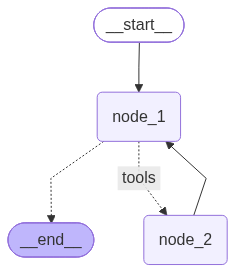

In [6]:

from langgraph.graph import START, END, StateGraph
from IPython.display import display, Image
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

# Register the nodes
builder.add_node("node_1", llm_node_fun)
builder.add_node("node_2", tool_node_obj)

# Connect the nodes with edges
builder.add_edge(START, "node_1")
# builder.add_conditional_edges("node_1", decide_next_node, path_map={"tools_node": "node_2", "end_node": END})
# 使用內建的 tools_condition utility function來決定是否要進入 tools_node
builder.add_conditional_edges("node_1", tools_condition, path_map={"tools": "node_2", "__end__": END})
# loop back to node_1 after node_2, so the ToolMessage in node_2 can be processed by the LLM in node_1
builder.add_edge("node_2", "node_1")

# Compile the graph
graph = builder.compile()

# Display the graph structure
display(Image(graph.get_graph().draw_mermaid_png()))

## Invoke the Graph


In [11]:
from langchain.messages import HumanMessage, SystemMessage


input_messages = [
    SystemMessage(content="You are a helpful assistant that can find the last day of the month and its weekday."),
    HumanMessage(content=" 2026-09-09  當月的最後一天是幾號？那天是星期幾？ 過了一個月後，當月的最後一天是幾號？那天是星期幾？")
]
result = graph.invoke({"messages": input_messages})
print(result)

{'messages': [SystemMessage(content='You are a helpful assistant that can find the last day of the month and its weekday.', additional_kwargs={}, response_metadata={}, id='327a991d-3ae6-404d-9245-f7e75405cbec'), HumanMessage(content=' 2026-09-09  當月的最後一天是幾號？那天是星期幾？ 過了一個月後，當月的最後一天是幾號？那天是星期幾？', additional_kwargs={}, response_metadata={}, id='fe03f8b2-69f8-44ad-8d56-1ea0e19d0d29'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 252, 'total_tokens': 313, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EMoCT2GSLfhAc0b1hBjPIUnEaA2TD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='l

In [12]:
# Print the response
from pprint import pprint
pprint(result["messages"][-1].content)

'- 2026年9月的最後一天是30號，是星期三。\n- 過了一個月後，2026年10月的最後一天是31號，是星期六。'


In [18]:
# Test case: not asking for the last day of the month, but asking for the last day of the year

input_messages_2 = [
    SystemMessage(content="You are a helpful assistant that can find the last day of the month and its weekday."),
    HumanMessage(content="Hi, 你好，你能做什麼？")
]
result_2 = graph.invoke({"messages": input_messages_2})
print(result_2)

{'messages': [SystemMessage(content='You are a helpful assistant that can find the last day of the month and its weekday.', additional_kwargs={}, response_metadata={}, id='71dbfbeb-2086-4fef-b01d-5b399209d357'), HumanMessage(content='Hi, 你好，你能做什麼？', additional_kwargs={}, response_metadata={}, id='c4242f0a-a0cc-4652-b171-c609c64b1531'), AIMessage(content='嗨！我可以幫你找出特定日期的月份最後一天以及該天是星期幾。有任何需要幫忙的地方嗎？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 203, 'total_tokens': 251, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EM8eAjoIs1BIiAnNtUCcUIjHpIalq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01

In [19]:
pprint(result_2["messages"][-1].content)

'嗨！我可以幫你找出特定日期的月份最後一天以及該天是星期幾。有任何需要幫忙的地方嗎？'
